<a href="https://colab.research.google.com/github/noobavenger/tumor_detection/blob/main/braintumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pip

In [ ]:
!pip install --upgrade setuptools wheel

In [ ]:
# Install required libraries
!pip install tensorflow
!pip install matplotlib
!pip install sklearn
!pip install scikit-image
!pip install pandas
!pip install numpy
!pip install seaborn

# Import necessary libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Download Brain Tumor MRI Dataset from Kaggle
!pip install kaggle



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0


In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

Number of glioma training images: 4
Number of meningioma training images: 4
Number of notumor training images: 4
Number of pituitary training images: 4
Number of glioma testing images: 4
Number of meningioma testing images: 4
Number of notumor testing images: 4
Number of pituitary testing images: 4
Found 4857 images belonging to 4 classes.
Found 855 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


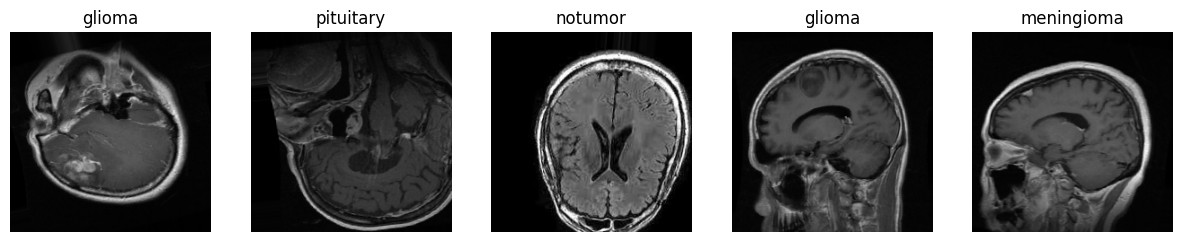

In [ ]:
data_dir = './Brain Tumor MRI Dataset'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Check data distribution
for cls in classes:
    path = os.path.join(data_dir, 'Training', cls)
    print(f"Number of {cls} training images: {len(os.listdir('/content/Brain Tumor MRI Dataset/Training'))}")

for cls in classes:
    path = os.path.join(data_dir, 'Testing', cls)
    print(f"Number of {cls} testing images: {len(os.listdir('/content/Brain Tumor MRI Dataset/Testing'))}")

# Set up image parameters
img_width, img_height = 224, 224
batch_size = 32

# Create data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators for training, validation and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Training'),
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Training'),
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Testing'),
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Display sample images
def display_samples(generator, num_samples=5):
    images, labels = next(generator)
    class_names = list(generator.class_indices.keys())

    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
    plt.show()

display_samples(train_generator)

In [ ]:
def build_model():
    model = Sequential([
        # First Convolution Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_width, img_height, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second Convolution Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Third Convolution Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(4, activation='softmax')  # 4 classes: glioma, meningioma, no tumor, pituitary
    ])

    return model

# Initialize the model
model = build_model()

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 25,981,220 (99.11 MB)

 Trainable params: 25,979,812 (99.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    'brain_tumor_model_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8219 - loss: 0.4688
Epoch 1: val_accuracy improved from -inf to 0.67067, saving model to brain_tumor_model_best.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 62s 411ms/step - accuracy: 0.8220 - loss: 0.4687 - val_accuracy: 0.6707 - val_loss: 0.9968 - learning_rate: 0.0010
Epoch 2/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7812 - loss: 0.5530

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.67067 to 0.68630, saving model to brain_tumor_model_best.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7812 - loss: 0.5530 - val_accuracy: 0.6863 - val_loss: 1.0004 - learning_rate: 0.0010
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8458 - loss: 0.4198
Epoch 3: val_accuracy did not improve from 0.68630
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 402ms/step - accuracy: 0.8458 - loss: 0.4198 - val_accuracy: 0.6142 - val_loss: 1.1969 - learning_rate: 0.0010
Epoch 4/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9062 - loss: 0.2422
Epoch 4: val_accuracy did not improve from 0.68630
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9062 - loss: 0.2422 - val_accuracy: 0.6142 - val_loss: 1.2204 - learning_rate: 0.0010
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8473 - loss: 0.3923
Epoch 5: val_accuracy improved from 0.68630 to 0.72716, saving model to brain_tumor_model_best.h5


...

151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9375 - loss: 0.2180 - val_accuracy: 0.7812 - val_loss: 0.6843 - learning_rate: 2.0000e-04
Epoch 17/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8755 - loss: 0.3454
Epoch 17: val_accuracy improved from 0.78125 to 0.84856, saving model to brain_tumor_model_best.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 62s 409ms/step - accuracy: 0.8756 - loss: 0.3452 - val_accuracy: 0.8486 - val_loss: 0.4456 - learning_rate: 2.0000e-04
Epoch 18/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8438 - loss: 0.3041
Epoch 18: val_accuracy improved from 0.84856 to 0.85337, saving model to brain_tumor_model_best.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8438 - loss: 0.3041 - val_accuracy: 0.8534 - val_loss: 0.4475 - learning_rate: 2.0000e-04
Epoch 19/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9005 - loss: 0.2932
Epoch 19: val_accuracy did not improve from 0.85337
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 405ms/step - accuracy: 0.9005 - loss: 0.2931 - val_accuracy: 0.7993 - val_loss: 0.5376 - learning_rate: 2.0000e-04
Epoch 20/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8750 - loss: 0.2208
Epoch 20: val_accuracy did not improve from 0.85337
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8750 - loss: 0.2208 - val_accuracy: 0.8065 - val_loss: 0.5497 - learning_rate: 2.0000e-04
Epoch 21/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8957 - loss: 0.2859
Epoch 21: val_accuracy did not improve from 0.85337
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 402ms/step - accuracy: 0.8957 - loss: 0.2860 - val_accuracy: 0.7596 - val_loss: 0.7887 - learning_rate: 

151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9062 - loss: 0.2345 - val_accuracy: 0.8594 - val_loss: 0.4420 - learning_rate: 4.0000e-05
Epoch 27/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8999 - loss: 0.2803
Epoch 27: val_accuracy did not improve from 0.85938
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 404ms/step - accuracy: 0.8999 - loss: 0.2803 - val_accuracy: 0.8450 - val_loss: 0.4453 - learning_rate: 4.0000e-05
Epoch 28/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9062 - loss: 0.1663
Epoch 28: val_accuracy did not improve from 0.85938
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9062 - loss: 0.1663 - val_accuracy: 0.8450 - val_loss: 0.4397 - learning_rate: 4.0000e-05
Epoch 29/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8927 - loss: 0.2913
Epoch 29: val_accuracy improved from 0.85938 to 0.86178, saving model to brain_tumor_model_best.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 406ms/step - accuracy: 0.8927 - loss: 0.2913 - val_accuracy: 0.8618 - val_loss: 0.4060 - learning_rate: 4.0000e-05
Epoch 30/30
  1/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8750 - loss: 0.2760
Epoch 30: val_accuracy did not improve from 0.86178
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8750 - loss: 0.2760 - val_accuracy: 0.8594 - val_loss: 0.4197 - learning_rate: 4.0000e-05
Restoring model weights from the end of the best epoch: 29.


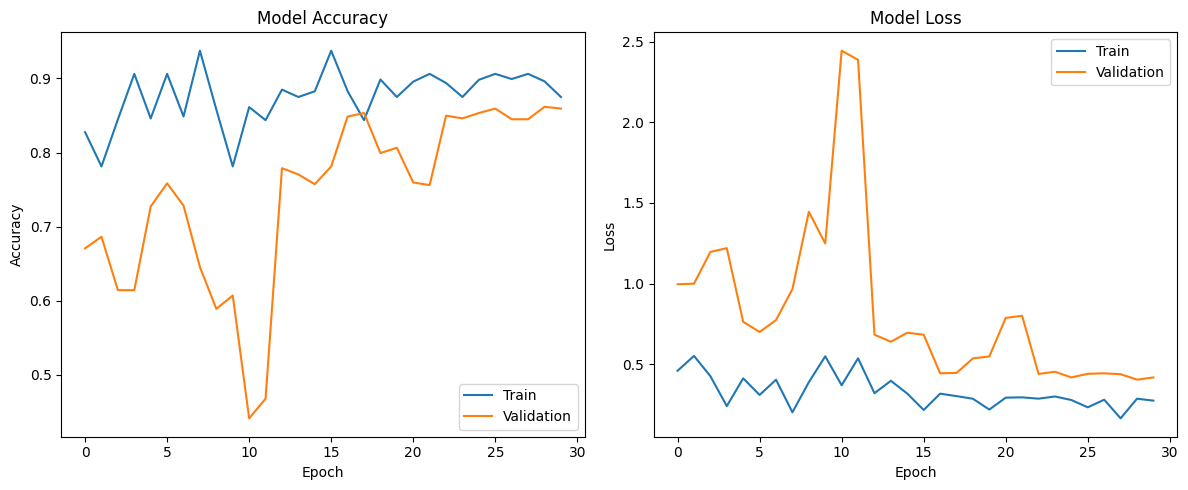

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7988 - loss: 0.5429
Test Accuracy: 0.8452
Test Loss: 0.4325
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.85      0.87       300
  meningioma       0.84      0.50      0.63       306
     notumor       0.87      0.99      0.92       405
   pituitary       0.79      1.00      0.88       300

    accuracy                           0.85      1311
   macro avg       0.85      0.83      0.83      1311
weighted avg       0.85      0.85      0.83      1311



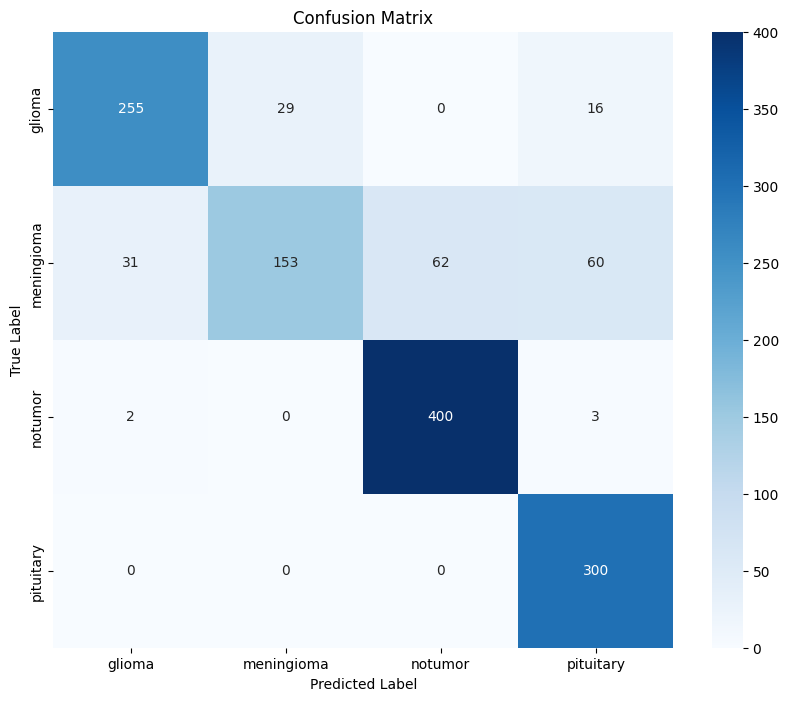

In [ ]:
def plot_history(history):
    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(history)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Confusion matrix and classification report
def evaluate_model(model, test_generator):
    # Get predictions
    test_generator.reset()
    # Convert steps to integer
    steps = int(np.ceil(test_generator.samples / batch_size))
    y_pred = model.predict(test_generator, steps=steps)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true labels
    y_true = test_generator.classes

    # Generate classification report
    class_names = list(test_generator.class_indices.keys())
    print("Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluate_model(model, test_generator)

True class: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


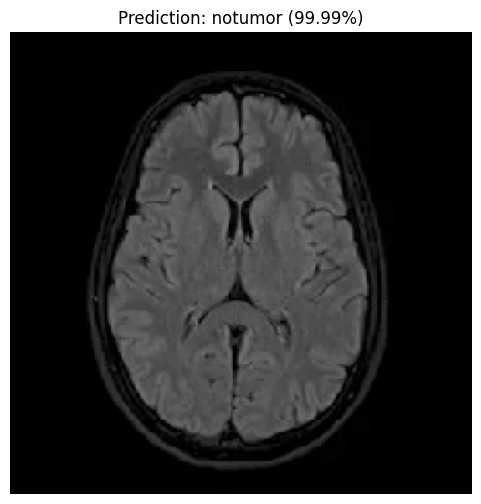

glioma: 0.00%
meningioma: 0.00%
notumor: 99.99%
pituitary: 0.01%


True class: glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


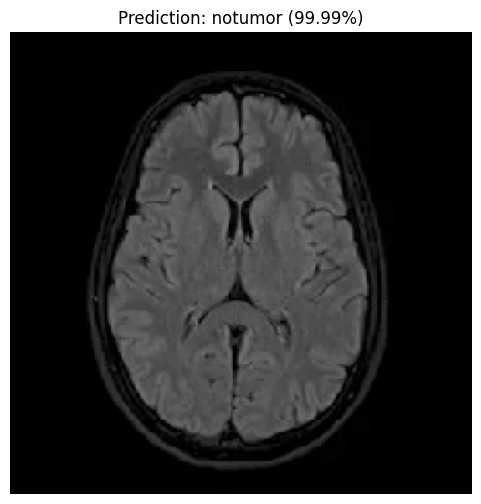

glioma: 0.00%
meningioma: 0.00%
notumor: 99.99%
pituitary: 0.01%


True class: glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


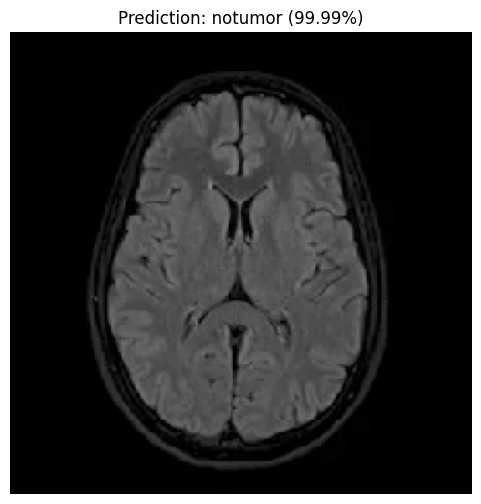

glioma: 0.00%
meningioma: 0.00%
notumor: 99.99%
pituitary: 0.01%


True class: glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


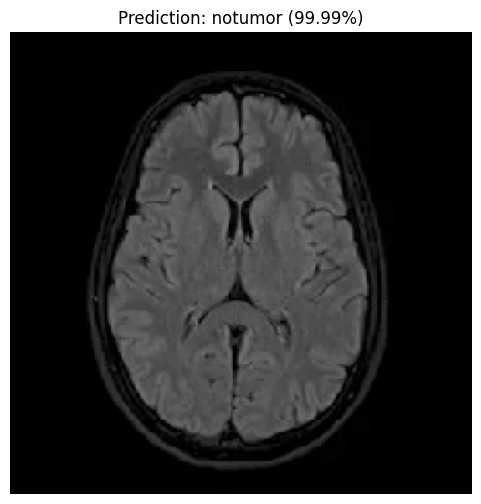

glioma: 0.00%
meningioma: 0.00%
notumor: 99.99%
pituitary: 0.01%


True class: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


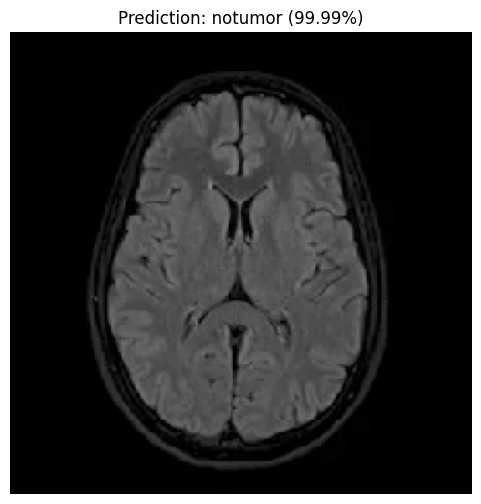

glioma: 0.00%
meningioma: 0.00%
notumor: 99.99%
pituitary: 0.01%




In [ ]:
def predict_image(image_path, model):
    from tensorflow.keras.preprocessing import image

    # Load and preprocess the image
    img = image.load_img('/content/Brain Tumor MRI Dataset/Testing/notumor/Te-noTr_0002.jpg', target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Make prediction
    prediction = model.predict(img_array)
    class_names = list(train_generator.class_indices.keys())
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f'Prediction: {predicted_class} ({confidence:.2f}%)')
    plt.axis('off')
    plt.show()
    for i, cls in enumerate(class_names):
        print(f"{cls}: {prediction[0][i]*100:.2f}%")
import random

def predict_random_test_images(model, test_dir, num_images=5):
    class_dirs = os.listdir(test_dir)

    for _ in range(num_images):
        random_class = random.choice(class_dirs)
        class_path = os.path.join(test_dir, random_class)
        random_image = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, random_image)
        print(f"True class: {random_class}")
        predict_image('/content/Brain Tumor MRI Dataset/Testing/notumor/Te-noTr_0002.jpg', model)
        print("\n")
predict_random_test_images(model, os.path.join(data_dir, 'Testing'))

In [ ]:
model.save('brain_tumor_detection_model.h5')

# Save as TensorFlow SavedModel format (for deployment)
model.export('brain_tumor_detection_savedmodel')

print("Model saved successfully!")

Saved artifact at 'brain_tumor_detection_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134879559692560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559693328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559692752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559696208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559695056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559695440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559696016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879559695632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879564432784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134879564431824: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [1]:
!apt-get install git!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package git!apt-get
E: Couldn't find any package by glob 'git!apt-get'
E: Unable to locate package install


In [2]:
!git config --global user.name "noobavenger"

In [3]:
!git config --global user.email "abhinav100h@gmail.com"

In [4]:
!git clone https://github.com/noobavenger/tumor_detection.git

Cloning into 'tumor_detection'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [5]:
!cp "/content/drive/MyDrive/Colab Notebooks/braintumor.ipynb"

cp: missing destination file operand after '/content/drive/MyDrive/Colab Notebooks/braintumor.ipynb'
Try 'cp --help' for more information.
